# Train Weather Forecasting Models


In [1]:
import copy
import io
import math
import random
import sys
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

CWD = Path.cwd().resolve()
SCRIPT_DIR = CWD if (CWD / "models.py").exists() else CWD / "FinalScripts"
REPO_ROOT = SCRIPT_DIR.parent if SCRIPT_DIR.name == "FinalScripts" else CWD
sys.path.insert(0, str(SCRIPT_DIR))

from models import GraphNN, GraphRNN, LSTMRegressor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print("SCRIPT_DIR:", SCRIPT_DIR)
print("DEVICE:", DEVICE)


SCRIPT_DIR: C:\Users\ke119419\Desktop\EEL6812\FinalProject\EEL6812_Final_Project\FinalScripts
DEVICE: cuda


## Settings


In [2]:
MODEL_NAME = "GraphRNN"
DATASET_NAME = "full_us"

DATASETS = {
    "full_us": {
        "node_path": SCRIPT_DIR / "GraphData/full_us_nodeList.csv",
        "edge_path": SCRIPT_DIR / "GraphData/full_us_edgeList.csv",
        "weather_root": SCRIPT_DIR / "WeatherData" / "full_us",
    },
    "florida": {
        "node_path": SCRIPT_DIR / "GraphData/florida_nodeList.csv",
        "edge_path": SCRIPT_DIR / "GraphData/florida_edgeList.csv",
        "weather_root": SCRIPT_DIR / "WeatherData" / "florida",
    },
}

SEED = 42
LOOKBACK = 24
TRAIN_RATIO = 0.80
VAL_RATIO = 0.20
EPOCHS = 100
PATIENCE = 15
BATCH_SIZE = 16 if MODEL_NAME in {"GraphNN", "GraphRNN"} else 256
LR = 5e-4 if MODEL_NAME in {"GraphNN", "GraphRNN"} else 1e-3
WEIGHT_DECAY = 5e-5
GRAD_CLIP = 2.0
DROPOUT = 0.15
EPS = 1e-6
MAX_NODES = None

GNN_HIDDEN_SIZE = 96
SAGE_HIDDEN_SIZE = 96
RNN_HIDDEN_SIZE = 96
HEAD_HIDDEN_SIZE = 64
LSTM_HIDDEN_SIZE = 64
LSTM_NUM_LAYERS = 1

CHECKPOINT_DIR = SCRIPT_DIR / "saved_models"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"{DATASET_NAME}_{MODEL_NAME}_checkpoint.pt"

FEATURE_NAMES = [
    "rain",
    "wind_speed",
    "temperature",
    "humidity",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos",
]
TEMP_FEATURE_IDX = FEATURE_NAMES.index("temperature")

if MODEL_NAME == "baseline_lstm":
    MNAME = "Baseline LSTM"
elif MODEL_NAME == "GraphRNN":
    MNAME = "GraphRNN"
else:
    MNAME = "GraphNN"

dataset_config = DATASETS[DATASET_NAME]
dataset_config


{'node_path': WindowsPath('C:/Users/ke119419/Desktop/EEL6812/FinalProject/EEL6812_Final_Project/FinalScripts/GraphData/full_us_nodeList.csv'),
 'edge_path': WindowsPath('C:/Users/ke119419/Desktop/EEL6812/FinalProject/EEL6812_Final_Project/FinalScripts/GraphData/full_us_edgeList.csv'),
 'weather_root': WindowsPath('C:/Users/ke119419/Desktop/EEL6812/FinalProject/EEL6812_Final_Project/FinalScripts/WeatherData/full_us')}

## Data Loading


In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def parse_weather_folder_name(folder_name):
    month, day, year_suffix = folder_name.split("_")
    return pd.Timestamp(year=2000 + int(year_suffix), month=int(month), day=int(day))


def load_feature_timeseries(weather_root, filename, node_ids):
    daily_frames = []
    daily_dates = []
    day_dirs = sorted(
        [path for path in weather_root.iterdir() if path.is_dir()],
        key=lambda path: parse_weather_folder_name(path.name),
    )

    for day_dir in day_dirs:
        csv_path = day_dir / filename
        if not csv_path.exists():
            continue

        daily_df = pd.read_csv(csv_path)
        daily_df["id"] = pd.to_numeric(daily_df["id"], errors="coerce").astype("Int64")
        daily_df = daily_df.set_index("id").reindex(node_ids)
        hour_cols = [col for col in daily_df.columns if col.startswith("hour_")]
        if len(hour_cols) != 24:
            raise ValueError(f"{csv_path} should have 24 hour columns, found {len(hour_cols)}")
        daily_df[hour_cols] = daily_df[hour_cols].astype(np.float32)
        daily_frames.append(daily_df[hour_cols])
        daily_dates.append(parse_weather_folder_name(day_dir.name))

    if not daily_frames:
        raise ValueError(f"No files named {filename} were found in {weather_root}.")

    return pd.concat(daily_frames, axis=1, ignore_index=True), daily_dates


def load_dataset(config):
    node_data = pd.read_csv(config["node_path"])
    edge_data = pd.read_csv(config["edge_path"])
    weather_root = Path(config["weather_root"])
    if MAX_NODES is not None:
        node_data = node_data.head(int(MAX_NODES)).copy()

    node_ids = pd.Index(pd.to_numeric(node_data["id"], errors="coerce").astype(int), name="id")
    if node_ids.has_duplicates:
        raise ValueError("Node IDs must be unique.")

    rain_features, weather_dates = load_feature_timeseries(weather_root, "rain_data.csv", node_ids)
    wind_features, wind_dates = load_feature_timeseries(weather_root, "wind_speed_data.csv", node_ids)
    temp_features, temp_dates = load_feature_timeseries(weather_root, "temp_data.csv", node_ids)
    humidity_features, humidity_dates = load_feature_timeseries(weather_root, "humidity_data.csv", node_ids)
    if not (weather_dates == wind_dates == temp_dates == humidity_dates):
        raise ValueError("Rain, wind speed, temperature, and humidity files are not aligned by day.")

    timestamps = []
    for day_ts in weather_dates:
        timestamps.extend(pd.date_range(day_ts, periods=24, freq="h"))
    timestamps = pd.DatetimeIndex(timestamps)

    hour = timestamps.hour.to_numpy(dtype=np.float32)
    month = timestamps.month.to_numpy(dtype=np.float32)
    doy = timestamps.dayofyear.to_numpy(dtype=np.float32)
    num_nodes = len(node_ids)

    dynamic_feature_tensor = np.stack(
        [
            rain_features.to_numpy(dtype=np.float32),
            wind_features.to_numpy(dtype=np.float32),
            temp_features.to_numpy(dtype=np.float32),
            humidity_features.to_numpy(dtype=np.float32),
            np.tile(np.sin(2 * np.pi * hour / 24.0), (num_nodes, 1)),
            np.tile(np.cos(2 * np.pi * hour / 24.0), (num_nodes, 1)),
            np.tile(np.sin(2 * np.pi * month / 12.0), (num_nodes, 1)),
            np.tile(np.cos(2 * np.pi * month / 12.0), (num_nodes, 1)),
            np.tile(np.sin(2 * np.pi * doy / 365.25), (num_nodes, 1)),
            np.tile(np.cos(2 * np.pi * doy / 365.25), (num_nodes, 1)),
        ],
        axis=-1,
    )
    target_tensor = temp_features.to_numpy(dtype=np.float32)

    static_cols = [col for col in ["latitude", "longitude", "elevation"] if col in node_data.columns]
    node_static_frame = node_data[static_cols].apply(pd.to_numeric, errors="coerce")
    node_static_frame = node_static_frame.fillna(node_static_frame.median(numeric_only=True)).fillna(0.0)
    node_static_frame = (node_static_frame - node_static_frame.mean()) / node_static_frame.std().clip(lower=EPS)

    id_to_pos = {int(node_id): pos for pos, node_id in enumerate(node_ids)}
    edge_sources = pd.to_numeric(edge_data["source"], errors="coerce").astype(int)
    edge_targets = pd.to_numeric(edge_data["target"], errors="coerce").astype(int)
    mapped_sources = edge_sources.map(id_to_pos)
    mapped_targets = edge_targets.map(id_to_pos)
    valid_edges = mapped_sources.notna() & mapped_targets.notna()
    if not valid_edges.all():
        print(f"Dropping {(~valid_edges).sum()} edges that reference missing node IDs.")
    edge_index_np = np.vstack([
        mapped_sources[valid_edges].to_numpy(dtype=np.int64),
        mapped_targets[valid_edges].to_numpy(dtype=np.int64),
    ])
    edge_weight_np = edge_data.loc[valid_edges, "weight"].to_numpy(dtype=np.float32)
    edge_weight_np = edge_weight_np / max(float(np.abs(edge_weight_np).max()), EPS)

    return {
        "node_data": node_data,
        "edge_data": edge_data,
        "node_ids": node_ids,
        "weather_dates": weather_dates,
        "timestamps": timestamps,
        "dynamic_feature_tensor": dynamic_feature_tensor,
        "target_tensor": target_tensor,
        "node_static_features": torch.tensor(node_static_frame.to_numpy(dtype=np.float32), dtype=torch.float32, device=DEVICE),
        "edge_index": torch.tensor(edge_index_np, dtype=torch.long, device=DEVICE),
        "edge_weight": torch.tensor(edge_weight_np, dtype=torch.float32, device=DEVICE),
        "edge_features": torch.tensor(edge_weight_np.reshape(-1, 1), dtype=torch.float32, device=DEVICE),
    }


In [4]:
set_seed()
data = load_dataset(dataset_config)
num_nodes = len(data["node_ids"])
num_timesteps = len(data["timestamps"])

print("dataset:", DATASET_NAME)
print("model:", MODEL_NAME)
print("loaded days:", len(data["weather_dates"]))
print("date range:", data["weather_dates"][0], "to", data["weather_dates"][-1])
print("num_nodes:", num_nodes)
print("num_timesteps:", num_timesteps)
print("dynamic tensor:", data["dynamic_feature_tensor"].shape)
print("edge_index:", tuple(data["edge_index"].shape))


dataset: full_us
model: GraphRNN
loaded days: 365
date range: 2018-01-01 00:00:00 to 2018-12-31 00:00:00
num_nodes: 2728
num_timesteps: 8760
dynamic tensor: (2728, 8760, 10)
edge_index: (2, 5203)


## Window Builders


In [5]:
def split_train_val_test(X_all, y_all, y_level_all, last_temp_all, pred_times, timestamps):
    split_idx = max(LOOKBACK + 1, int(len(timestamps) * TRAIN_RATIO))
    pred_times = np.asarray(pred_times)
    pred_timestamps = timestamps[pred_times]

    train_full_mask = pred_times < split_idx
    test_mask = pred_times >= split_idx

    X_train_full = X_all[train_full_mask]
    y_train_full = y_all[train_full_mask]
    X_test = X_all[test_mask]
    y_test = y_all[test_mask]
    y_test_level = y_level_all[test_mask]
    last_temp_test = last_temp_all[test_mask]
    test_timestamps = pred_timestamps[test_mask]

    if len(X_train_full) < 2:
        raise ValueError("Not enough training windows. Reduce LOOKBACK or use more data.")

    val_start = int(len(X_train_full) * (1 - VAL_RATIO))
    val_start = min(max(val_start, 1), len(X_train_full) - 1)

    return {
        "X_train": X_train_full[:val_start],
        "y_train": y_train_full[:val_start],
        "X_val": X_train_full[val_start:],
        "y_val": y_train_full[val_start:],
        "X_test": X_test,
        "y_test": y_test,
        "y_test_level": y_test_level,
        "last_temp_test": last_temp_test,
        "test_timestamps": test_timestamps,
        "split_idx": split_idx,
    }


def build_GraphNN_windows(data):
    dyn = data["dynamic_feature_tensor"]
    target = data["target_tensor"]
    split_idx = max(LOOKBACK + 1, int(dyn.shape[1] * TRAIN_RATIO))

    dynamic_mean = dyn[:, :split_idx, :].mean(axis=1, keepdims=True)
    dynamic_std = np.clip(dyn[:, :split_idx, :].std(axis=1, keepdims=True), EPS, None)
    target_mean = target[:, :split_idx].mean(axis=1, keepdims=True)
    target_std = np.clip(target[:, :split_idx].std(axis=1, keepdims=True), EPS, None)
    dyn_scaled = (dyn - dynamic_mean) / dynamic_std
    target_scaled = (target - target_mean) / target_std

    X_all, y_all, y_level_all, last_temp_all, pred_times = [], [], [], [], []
    for t in range(LOOKBACK, dyn.shape[1]):
        window = dyn_scaled[:, t - LOOKBACK : t, :].reshape(dyn.shape[0], -1)
        last_temp = dyn_scaled[:, t - 1, TEMP_FEATURE_IDX]
        next_temp = target_scaled[:, t]
        X_all.append(window.astype(np.float32))
        y_all.append((next_temp - last_temp).astype(np.float32))
        y_level_all.append(next_temp.astype(np.float32))
        last_temp_all.append(last_temp.astype(np.float32))
        pred_times.append(t)

    parts = split_train_val_test(
        torch.tensor(np.stack(X_all), dtype=torch.float32),
        torch.tensor(np.stack(y_all), dtype=torch.float32),
        torch.tensor(np.stack(y_level_all), dtype=torch.float32),
        torch.tensor(np.stack(last_temp_all), dtype=torch.float32),
        pred_times,
        data["timestamps"],
    )
    parts.update({
        "target_mean": torch.tensor(target_mean.squeeze(1), dtype=torch.float32).unsqueeze(0),
        "target_std": torch.tensor(target_std.squeeze(1), dtype=torch.float32).unsqueeze(0),
    })
    return parts


def build_GraphRNN_windows(data):
    dyn = data["dynamic_feature_tensor"]
    target = data["target_tensor"]
    split_idx = max(LOOKBACK + 1, int(dyn.shape[1] * TRAIN_RATIO))

    dynamic_mean = dyn[:, :split_idx, :].mean(axis=1, keepdims=True)
    dynamic_std = np.clip(dyn[:, :split_idx, :].std(axis=1, keepdims=True), EPS, None)
    temp_mean = dynamic_mean[:, :, TEMP_FEATURE_IDX].squeeze(1)
    temp_std = dynamic_std[:, :, TEMP_FEATURE_IDX].squeeze(1)
    dyn_scaled = (dyn - dynamic_mean) / dynamic_std

    X_all, y_all, y_level_all, last_temp_all, pred_times = [], [], [], [], []
    for t in range(LOOKBACK, dyn.shape[1]):
        window = dyn_scaled[:, t - LOOKBACK : t, :]
        X_all.append(np.transpose(window, (0, 2, 1)).reshape(dyn.shape[0] * dyn.shape[2], LOOKBACK).astype(np.float32))
        last_temp = dyn_scaled[:, t - 1, TEMP_FEATURE_IDX]
        next_temp = dyn_scaled[:, t, TEMP_FEATURE_IDX]
        y_all.append((next_temp - last_temp).astype(np.float32))
        y_level_all.append(next_temp.astype(np.float32))
        last_temp_all.append(last_temp.astype(np.float32))
        pred_times.append(t)

    parts = split_train_val_test(
        torch.tensor(np.stack(X_all), dtype=torch.float32),
        torch.tensor(np.stack(y_all), dtype=torch.float32),
        torch.tensor(np.stack(y_level_all), dtype=torch.float32),
        torch.tensor(np.stack(last_temp_all), dtype=torch.float32),
        pred_times,
        data["timestamps"],
    )
    parts.update({"target_mean": torch.tensor(temp_mean, dtype=torch.float32).unsqueeze(0), "target_std": torch.tensor(temp_std, dtype=torch.float32).unsqueeze(0)})
    return parts


def build_baseline_lstm_windows(data):
    dyn = data["dynamic_feature_tensor"]
    split_idx = max(LOOKBACK + 1, int(dyn.shape[1] * TRAIN_RATIO))
    X_train_full, y_train_full, X_test, y_test = [], [], [], []
    y_test_level, last_temp_test, test_mean, test_std, test_station, test_time = [], [], [], [], [], []

    for node_pos, node_id in enumerate(data["node_ids"]):
        series = dyn[node_pos]
        mean = series[:split_idx].mean(axis=0)
        std = np.clip(series[:split_idx].std(axis=0), EPS, None)
        scaled = (series - mean) / std
        for t in range(LOOKBACK, dyn.shape[1]):
            x = scaled[t - LOOKBACK : t].astype(np.float32)
            last_temp = scaled[t - 1, TEMP_FEATURE_IDX]
            next_temp = scaled[t, TEMP_FEATURE_IDX]
            y = np.array([next_temp - last_temp], dtype=np.float32)
            if t < split_idx:
                X_train_full.append(x)
                y_train_full.append(y)
            else:
                X_test.append(x)
                y_test.append(y)
                y_test_level.append([next_temp])
                last_temp_test.append([last_temp])
                test_mean.append([mean[TEMP_FEATURE_IDX]])
                test_std.append([std[TEMP_FEATURE_IDX]])
                test_station.append(int(node_id))
                test_time.append(data["timestamps"][t])

    X_train_full = torch.tensor(np.asarray(X_train_full), dtype=torch.float32)
    y_train_full = torch.tensor(np.asarray(y_train_full), dtype=torch.float32)
    val_start = int(len(X_train_full) * (1 - VAL_RATIO))
    val_start = min(max(val_start, 1), len(X_train_full) - 1)
    return {
        "X_train": X_train_full[:val_start],
        "y_train": y_train_full[:val_start],
        "X_val": X_train_full[val_start:],
        "y_val": y_train_full[val_start:],
        "X_test": torch.tensor(np.asarray(X_test), dtype=torch.float32),
        "y_test": torch.tensor(np.asarray(y_test), dtype=torch.float32),
        "y_test_level": torch.tensor(np.asarray(y_test_level), dtype=torch.float32),
        "last_temp_test": torch.tensor(np.asarray(last_temp_test), dtype=torch.float32),
        "target_mean": torch.tensor(np.asarray(test_mean), dtype=torch.float32),
        "target_std": torch.tensor(np.asarray(test_std), dtype=torch.float32),
        "test_station_ids": test_station,
        "test_timestamps": pd.DatetimeIndex(test_time),
        "split_idx": split_idx,
    }


## Train Model


In [6]:
def make_loaders(parts):
    train_dataset = TensorDataset(parts["X_train"], parts["y_train"])
    val_dataset = TensorDataset(parts["X_val"], parts["y_val"])
    test_dataset = TensorDataset(parts["X_test"], parts["y_test"])
    batch_size = min(BATCH_SIZE, len(train_dataset)) if len(train_dataset) else 1
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=DEVICE.type == "cuda"),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=DEVICE.type == "cuda"),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=DEVICE.type == "cuda"),
    )


def make_model(model_name, data, parts):
    if model_name == "GraphNN":
        return GraphNN(
            num_nodes=len(data["node_ids"]),
            node_static_dim=data["node_static_features"].shape[1],
            node_window_dim=parts["X_train"].shape[-1],
            gnn_hidden_size=GNN_HIDDEN_SIZE,
            head_hidden_size=HEAD_HIDDEN_SIZE,
            dropout=DROPOUT,
        ).to(DEVICE)
    if model_name == "GraphRNN":
        return GraphRNN(
            num_nodes=len(data["node_ids"]),
            num_node_features=data["node_static_features"].shape[1],
            num_edge_features=1,
            num_weather_features=len(FEATURE_NAMES),
            sage_hidden_size=SAGE_HIDDEN_SIZE,
            rnn_hidden_size=RNN_HIDDEN_SIZE,
            head_hidden_size=HEAD_HIDDEN_SIZE,
            num_targets_per_node=1,
            dropout=DROPOUT,
        ).to(DEVICE)
    if model_name == "baseline_lstm":
        return LSTMRegressor(
            input_size=parts["X_train"].shape[-1],
            hidden_size=LSTM_HIDDEN_SIZE,
            num_layers=LSTM_NUM_LAYERS,
        ).to(DEVICE)
    raise ValueError(f"Unknown MODEL_NAME: {model_name}")


def forward_model(model, model_name, Xb, data):
    if model_name == "GraphNN":
        return model(data["node_static_features"], data["edge_index"], data["edge_weight"], Xb)
    if model_name == "GraphRNN":
        return model(data["node_static_features"], data["edge_features"], Xb, data["edge_index"])
    if model_name == "baseline_lstm":
        return model(Xb)
    raise ValueError(model_name)


def train_selected_model(model, model_name, data, parts):
    train_loader, val_loader, test_loader = make_loaders(parts)
    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-6)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    print("train samples:", len(train_loader.dataset))
    print("val samples:", len(val_loader.dataset))
    print("test samples:", len(test_loader.dataset))
    print("train input shape:", tuple(parts["X_train"].shape))
    print("train target shape:", tuple(parts["y_train"].shape))

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        for Xb, yb in train_loader:
            Xb = Xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            preds = forward_model(model, model_name, Xb, data)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            total_train += loss.item() * Xb.size(0)
        train_loss = total_train / max(len(train_loader.dataset), 1)
        train_losses.append(train_loss)

        model.eval()
        total_val = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                preds = forward_model(model, model_name, Xb, data)
                total_val += criterion(preds, yb).item() * Xb.size(0)
        val_loss = total_val / max(len(val_loader.dataset), 1)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch == 1 or epoch % 5 == 0:
            mark = "*" if epoch == best_epoch else " "
            print(f"epoch {epoch:03d}{mark} train={train_loss:.5f} val={val_loss:.5f} lr={optimizer.param_groups[0]['lr']:.2e}")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    pred_chunks = []
    with torch.no_grad():
        model.eval()
        for Xb, _ in test_loader:
            pred_chunks.append(forward_model(model, model_name, Xb.to(DEVICE, non_blocking=True), data).cpu())
    pred_delta = torch.cat(pred_chunks, dim=0) if pred_chunks else torch.empty_like(parts["y_test"])
    pred_scaled = pred_delta + parts["last_temp_test"]
    truth_scaled = parts["y_test_level"]
    target_mean = parts["target_mean"]
    target_std = parts["target_std"]
    pred = pred_scaled * target_std + target_mean
    truth = truth_scaled * target_std + target_mean
    test_mae = torch.mean(torch.abs(pred - truth)).item() if len(pred) else float("nan")
    test_rmse = torch.sqrt(torch.mean((pred - truth) ** 2)).item() if len(pred) else float("nan")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "pred": pred,
        "truth": truth,
    }


In [7]:
if MODEL_NAME == "GraphNN":
    parts = build_GraphNN_windows(data)
elif MODEL_NAME == "GraphRNN":
    parts = build_GraphRNN_windows(data)
elif MODEL_NAME == "baseline_lstm":
    parts = build_baseline_lstm_windows(data)
else:
    raise ValueError(f"Unknown MODEL_NAME: {MODEL_NAME}")

model = make_model(MODEL_NAME, data, parts)
result = train_selected_model(model, MODEL_NAME, data, parts)

print(f"best epoch: {result['best_epoch']}")
print(f"best val loss: {result['best_val_loss']:.5f}")
print(f"test MAE: {result['test_mae']:.5f}")
print(f"test RMSE: {result['test_rmse']:.5f}")


train samples: 5587
val samples: 1397
test samples: 1752
train input shape: (5587, 27280, 24)
train target shape: (5587, 2728)
epoch 001* train=0.00787 val=0.00545 lr=5.00e-04
epoch 005  train=0.00532 val=0.00466 lr=5.00e-04
epoch 010  train=0.00501 val=0.00452 lr=5.00e-04
epoch 015  train=0.00468 val=0.00433 lr=5.00e-04
epoch 020  train=0.00458 val=0.00438 lr=5.00e-04
epoch 025  train=0.00441 val=0.00430 lr=5.00e-04
epoch 030  train=0.00433 val=0.00401 lr=5.00e-04
epoch 035* train=0.00428 val=0.00393 lr=5.00e-04
epoch 040* train=0.00424 val=0.00388 lr=5.00e-04
epoch 045  train=0.00420 val=0.00389 lr=5.00e-04
epoch 050  train=0.00418 val=0.00391 lr=5.00e-04
epoch 055  train=0.00415 val=0.00397 lr=5.00e-04
Early stopping at epoch 58.
best epoch: 43
best val loss: 0.00385
test MAE: 1.02703
test RMSE: 1.51464


## Loss Curves


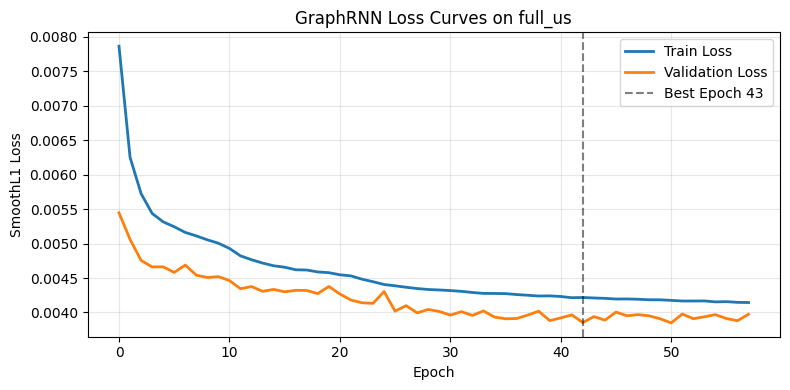

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(result["train_losses"], label="Train Loss", linewidth=2)
plt.plot(result["val_losses"], label="Validation Loss", linewidth=2)

best_epoch = int(result["best_epoch"])
if best_epoch > 0:
    plt.axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label=f"Best Epoch {best_epoch}")


plt.title(f"{MNAME} Loss Curves on {DATASET_NAME}")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Save Checkpoint


In [9]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "model_name": MODEL_NAME,
    "model_class": model.__class__.__name__,
    "model_state_dict": model.state_dict(),
    "dataset_name": DATASET_NAME,
    "dataset_config": {key: str(value) for key, value in dataset_config.items()},
    "config": {
        "lookback": LOOKBACK,
        "train_ratio": TRAIN_RATIO,
        "val_ratio": VAL_RATIO,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "dropout": DROPOUT,
        "feature_names": FEATURE_NAMES,
        "temp_feature_idx": TEMP_FEATURE_IDX,
        "num_nodes": len(data["node_ids"]),
        "num_timesteps": len(data["timestamps"]),
    },
    "metrics": {
        "best_epoch": result["best_epoch"],
        "best_val_loss": result["best_val_loss"],
        "test_mae": result["test_mae"],
        "test_rmse": result["test_rmse"],
    },
    "train_losses": result["train_losses"],
    "val_losses": result["val_losses"],
    "node_ids": data["node_ids"].to_numpy(dtype=int),
    "node_features": data["node_static_features"].detach().cpu(),
    "edge_index": data["edge_index"].detach().cpu(),
    "edge_weight": data["edge_weight"].detach().cpu(),
    "X_test": parts["X_test"].detach().cpu(),
    "y_test_level": parts["y_test_level"].detach().cpu(),
    "last_temp_test": parts["last_temp_test"].detach().cpu(),
    "target_mean": parts["target_mean"].detach().cpu(),
    "target_std": parts["target_std"].detach().cpu(),
    "test_timestamps": parts["test_timestamps"].astype(str).tolist(),
}

if MODEL_NAME == "baseline_lstm":
    checkpoint["test_station_ids"] = parts["test_station_ids"]

torch.save(checkpoint, CHECKPOINT_PATH)
print(f"Saved checkpoint to {CHECKPOINT_PATH.resolve()}")


Saved checkpoint to C:\Users\ke119419\Desktop\EEL6812\FinalProject\EEL6812_Final_Project\FinalScripts\saved_models\full_us_GraphRNN_checkpoint.pt


## Test Visualizations


In [10]:
PLOT_NODE_ID = None
PLOT_HOURS = 24 * 7
GRAPH_FRAME_INDEX = 0


def build_prediction_long_frame(result, data, parts, model_name):
    pred = result["pred"].detach().cpu().numpy()
    truth = result["truth"].detach().cpu().numpy()

    if model_name in {"GraphNN", "GraphRNN"}:
        node_ids = data["node_ids"].to_numpy(dtype=int)
        timestamps = pd.DatetimeIndex(parts["test_timestamps"])
        return pd.DataFrame(
            {
                "timestamp": np.repeat(timestamps.to_numpy(), len(node_ids)),
                "node_id": np.tile(node_ids, len(timestamps)),
                "actual": truth.reshape(-1),
                "predicted": pred.reshape(-1),
            }
        )

    if model_name == "baseline_lstm":
        return pd.DataFrame(
            {
                "timestamp": pd.DatetimeIndex(parts["test_timestamps"]).to_numpy(),
                "node_id": np.asarray(parts["test_station_ids"], dtype=int),
                "actual": truth.reshape(-1),
                "predicted": pred.reshape(-1),
            }
        )

    raise ValueError(model_name)


prediction_df = build_prediction_long_frame(result, data, parts, MODEL_NAME)
prediction_df["error"] = prediction_df["predicted"] - prediction_df["actual"]
prediction_df.head()


,timestamp,node_id,actual,predicted,error
0,2018-10-20,1,51.259998,51.813732,0.553734
1,2018-10-20,2,55.820000,54.950928,-0.869072
2,2018-10-20,3,55.160000,53.415596,-1.744404
3,2018-10-20,4,46.700001,46.455578,-0.244423
4,2018-10-20,5,50.060001,49.920929,-0.139072


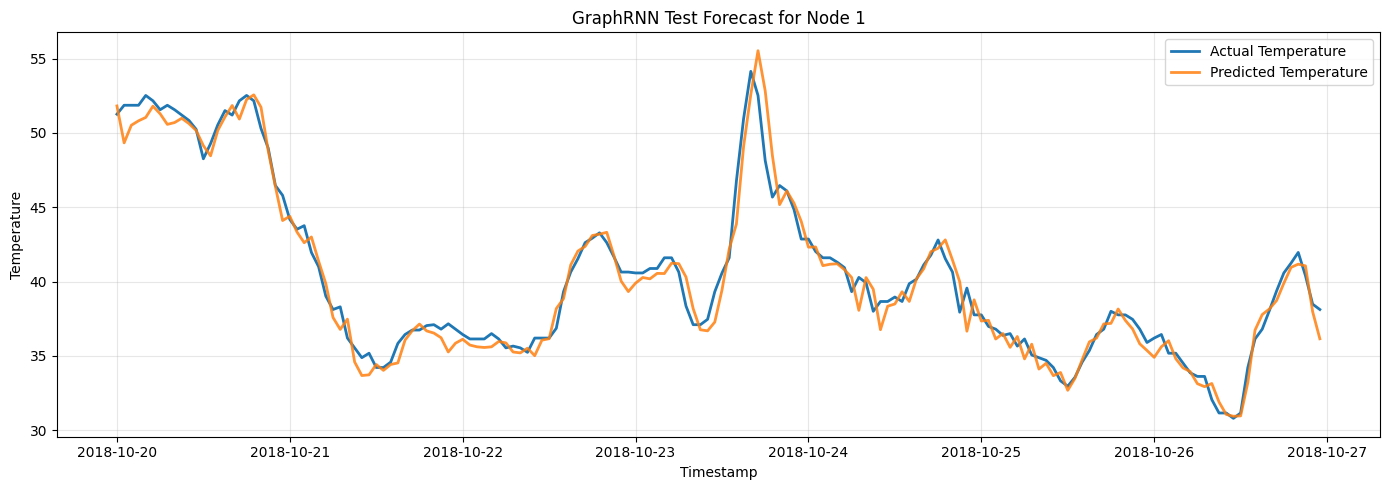

In [11]:
node_ids = data["node_ids"].to_numpy(dtype=int)
plot_node_id = int(node_ids[0] if PLOT_NODE_ID is None else PLOT_NODE_ID)
node_series = prediction_df[prediction_df["node_id"] == plot_node_id].sort_values("timestamp")

if node_series.empty:
    raise ValueError(f"Node {plot_node_id} was not found in the test predictions.")

plot_series = node_series.head(PLOT_HOURS)

plt.figure(figsize=(14, 5))
plt.plot(plot_series["timestamp"], plot_series["actual"], label="Actual Temperature", linewidth=2)
plt.plot(plot_series["timestamp"], plot_series["predicted"], label="Predicted Temperature", linewidth=2, alpha=0.85)
plt.title(f"{MNAME} Test Forecast for Node {plot_node_id}")
plt.xlabel("Timestamp")
plt.ylabel("Temperature")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


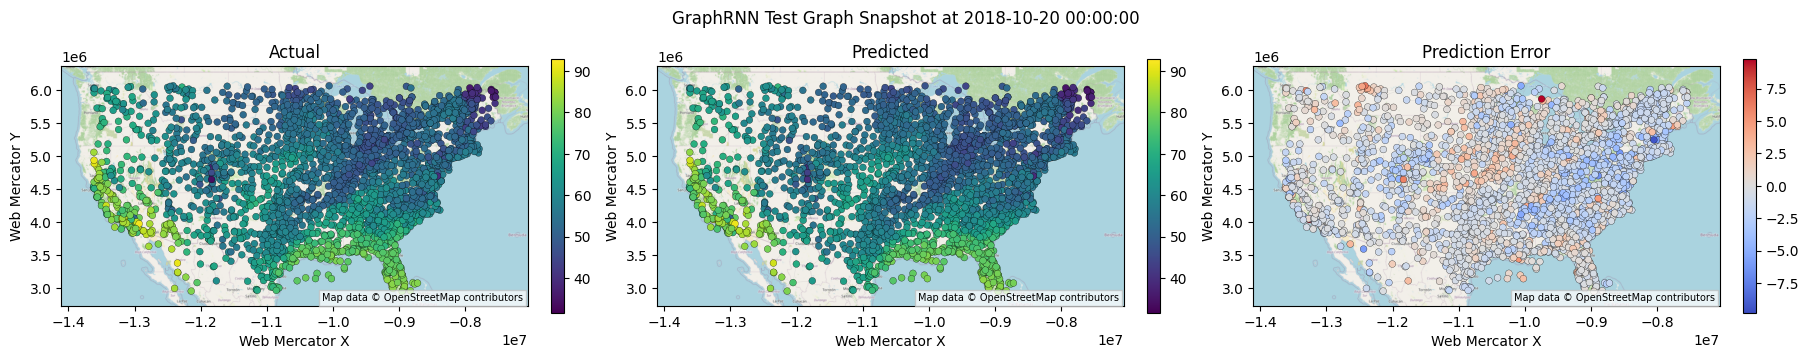

In [12]:
import io
import math
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

import matplotlib.image as mpimg

if "SCRIPT_DIR" not in globals():
    CWD = Path.cwd().resolve()
    SCRIPT_DIR = CWD if (CWD / "models.py").exists() else CWD / "FinalScripts"

WEB_MERCATOR_RADIUS = 6_378_137.0
MAX_MERCATOR_LAT = 85.05112878
OSM_TILE_URL = "https://tile.openstreetmap.org/{z}/{x}/{y}.png"
OSM_USER_AGENT = "EEL6812-weather-test-plotter/1.0"
OSM_TILE_ZOOM = 5
OSM_TILE_CACHE_DIR = SCRIPT_DIR / "tile_cache" / "osm"


def lonlat_to_mercator(lon, lat):
    lon_array = np.asarray(lon, dtype=float)
    lat_array = np.clip(np.asarray(lat, dtype=float), -MAX_MERCATOR_LAT, MAX_MERCATOR_LAT)
    x = WEB_MERCATOR_RADIUS * np.radians(lon_array)
    y = WEB_MERCATOR_RADIUS * np.log(np.tan(np.pi / 4.0 + np.radians(lat_array) / 2.0))
    return x, y


def lonlat_to_tile(lon, lat, zoom):
    lat = float(np.clip(lat, -MAX_MERCATOR_LAT, MAX_MERCATOR_LAT))
    lat_rad = math.radians(lat)
    n = 2**zoom
    x_tile = int((lon + 180.0) / 360.0 * n)
    y_tile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return max(0, min(n - 1, x_tile)), max(0, min(n - 1, y_tile))


def tile_bounds_mercator(x_tile, y_tile, zoom):
    n = 2**zoom
    lon_left = x_tile / n * 360.0 - 180.0
    lon_right = (x_tile + 1) / n * 360.0 - 180.0
    lat_top = math.degrees(math.atan(math.sinh(math.pi * (1.0 - 2.0 * y_tile / n))))
    lat_bottom = math.degrees(math.atan(math.sinh(math.pi * (1.0 - 2.0 * (y_tile + 1) / n))))
    x_left, y_bottom = lonlat_to_mercator(lon_left, lat_bottom)
    x_right, y_top = lonlat_to_mercator(lon_right, lat_top)
    return float(x_left), float(x_right), float(y_bottom), float(y_top)


def load_osm_tile(x_tile, y_tile, zoom, cache_dir):
    tile_path = cache_dir / str(zoom) / str(x_tile) / f"{y_tile}.png"
    if not tile_path.exists():
        tile_path.parent.mkdir(parents=True, exist_ok=True)
        url = OSM_TILE_URL.format(z=zoom, x=x_tile, y=y_tile)
        request = Request(url, headers={"User-Agent": OSM_USER_AGENT})
        try:
            with urlopen(request, timeout=30) as response:
                tile_path.write_bytes(response.read())
        except (HTTPError, URLError, TimeoutError) as exc:
            raise RuntimeError(f"Could not fetch OpenStreetMap tile {zoom}/{x_tile}/{y_tile}: {exc}") from exc
    return mpimg.imread(io.BytesIO(tile_path.read_bytes()), format="png")


def lonlat_bounds(node_frame):
    lon = pd.to_numeric(node_frame["longitude"], errors="coerce").dropna()
    lat = pd.to_numeric(node_frame["latitude"], errors="coerce").dropna()
    if lon.empty or lat.empty:
        return -126.0, -66.0, 23.0, 50.5
    lon_pad = max(float(lon.max() - lon.min()) * 0.08, 1.0)
    lat_pad = max(float(lat.max() - lat.min()) * 0.08, 1.0)
    return float(lon.min() - lon_pad), float(lon.max() + lon_pad), float(lat.min() - lat_pad), float(lat.max() + lat_pad)


def draw_osm_basemap(ax, bounds, zoom=OSM_TILE_ZOOM):
    lon_min, lon_max, lat_min, lat_max = bounds
    x_min_tile, y_max_tile = lonlat_to_tile(lon_min, lat_min, zoom)
    x_max_tile, y_min_tile = lonlat_to_tile(lon_max, lat_max, zoom)
    ax.set_facecolor("#dcecf5")
    for x_tile in range(x_min_tile, x_max_tile + 1):
        for y_tile in range(y_min_tile, y_max_tile + 1):
            image = load_osm_tile(x_tile, y_tile, zoom, OSM_TILE_CACHE_DIR)
            extent = tile_bounds_mercator(x_tile, y_tile, zoom)
            ax.imshow(image, extent=extent, origin="upper", zorder=0, interpolation="bilinear")


def set_map_extent(ax, bounds):
    lon_min, lon_max, lat_min, lat_max = bounds
    x_min, y_min = lonlat_to_mercator(lon_min, lat_min)
    x_max, y_max = lonlat_to_mercator(lon_max, lat_max)
    ax.set_xlim(float(x_min), float(x_max))
    ax.set_ylim(float(y_min), float(y_max))
    ax.set_aspect("equal", adjustable="box")


def draw_prediction_graph_snapshot(prediction_df, data, frame_index=GRAPH_FRAME_INDEX):
    timestamps = pd.DatetimeIndex(sorted(prediction_df["timestamp"].unique()))
    if len(timestamps) == 0:
        raise ValueError("No test timestamps are available to plot.")

    timestamp = timestamps[frame_index]
    frame = prediction_df[pd.to_datetime(prediction_df["timestamp"]) == timestamp].copy()
    if frame.empty:
        raise ValueError(f"No predictions are available for {timestamp}.")

    node_frame = data["node_data"][["id", "longitude", "latitude"]].copy()
    node_frame["id"] = pd.to_numeric(node_frame["id"], errors="coerce").astype(int)
    node_frame["longitude"] = pd.to_numeric(node_frame["longitude"], errors="coerce")
    node_frame["latitude"] = pd.to_numeric(node_frame["latitude"], errors="coerce")
    node_frame["x_mercator"], node_frame["y_mercator"] = lonlat_to_mercator(
        node_frame["longitude"].to_numpy(dtype=float),
        node_frame["latitude"].to_numpy(dtype=float),
    )
    frame = node_frame.merge(frame, left_on="id", right_on="node_id", how="inner")

    edge_frame = data["edge_data"][["source", "target"]].copy()
    edge_frame["source"] = pd.to_numeric(edge_frame["source"], errors="coerce").astype(int)
    edge_frame["target"] = pd.to_numeric(edge_frame["target"], errors="coerce").astype(int)
    pos = {
        int(row.id): (float(row.x_mercator), float(row.y_mercator))
        for row in node_frame.dropna(subset=["x_mercator", "y_mercator"]).itertuples(index=False)
    }
    bounds = lonlat_bounds(node_frame)

    value_min = float(min(frame["actual"].min(), frame["predicted"].min()))
    value_max = float(max(frame["actual"].max(), frame["predicted"].max()))
    err_abs = float(np.nanmax(np.abs(frame["error"]))) if len(frame) else 1.0
    err_abs = max(err_abs, 1e-6)

    fig, axes = plt.subplots(1, 3, figsize=(18, 3.5), constrained_layout=True)
    panels = [
        ("actual", "Actual", "viridis", value_min, value_max),
        ("predicted", "Predicted", "viridis", value_min, value_max),
        ("error", "Prediction Error", "coolwarm", -err_abs, err_abs),
    ]

    for ax, (column, title, cmap, vmin, vmax) in zip(axes, panels):
        draw_osm_basemap(ax, bounds)
        for edge in edge_frame.itertuples(index=False):
            source = int(edge.source)
            target = int(edge.target)
            if source in pos and target in pos:
                xs = [pos[source][0], pos[target][0]]
                ys = [pos[source][1], pos[target][1]]
                ax.plot(xs, ys, color="0.75", linewidth=0.35, alpha=0.35, zorder=1)

        scatter = ax.scatter(
            frame["x_mercator"],
            frame["y_mercator"],
            c=frame[column],
            cmap=cmap,
            s=24,
            edgecolors="black",
            linewidths=0.2,
            vmin=vmin,
            vmax=vmax,
            zorder=2,
        )
        ax.set_title(title)
        ax.set_xlabel("Web Mercator X")
        ax.set_ylabel("Web Mercator Y")
        set_map_extent(ax, bounds)
        ax.grid(False)
        ax.text(
            0.99,
            0.02,
            "Map data © OpenStreetMap contributors",
            transform=ax.transAxes,
            ha="right",
            fontsize=7,
            bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.75, "pad": 2},
        )
        fig.colorbar(scatter, ax=ax, shrink=0.85)

    fig.suptitle(f"{MNAME} Test Graph Snapshot at {timestamp}")
    plt.show()


draw_prediction_graph_snapshot(prediction_df, data)
